In [40]:
import pandas as pd
import matplotlib.pyplot as plt

train = pd.read_csv("/Users/pitzsb1/Documents/HBAC/train.csv")

train.head()

# HMS 데이터에서 “어떤 이상 EEG가 얼마나 부족한지” 숫자로 확인

,eeg_id,eeg_sub_id,eeg_label_offset_seconds,spectrogram_id,spectrogram_sub_id,spectrogram_label_offset_seconds,label_id,patient_id,expert_consensus,seizure_vote,lpd_vote,gpd_vote,lrda_vote,grda_vote,other_vote
0,1628180742,0,0.0,353733,0,0.0,127492639,42516,Seizure,3,0,0,0,0,0
1,1628180742,1,6.0,353733,1,6.0,3887563113,42516,Seizure,3,0,0,0,0,0
2,1628180742,2,8.0,353733,2,8.0,1142670488,42516,Seizure,3,0,0,0,0,0
3,1628180742,3,18.0,353733,3,18.0,2718991173,42516,Seizure,3,0,0,0,0,0
4,1628180742,4,24.0,353733,4,24.0,3080632009,42516,Seizure,3,0,0,0,0,0


(106800, 15)
Index(['eeg_id', 'eeg_sub_id', 'eeg_label_offset_seconds', 'spectrogram_id',
       'spectrogram_sub_id', 'spectrogram_label_offset_seconds', 'label_id',
       'patient_id', 'expert_consensus', 'seizure_vote', 'lpd_vote',
       'gpd_vote', 'lrda_vote', 'grda_vote', 'other_vote'],
      dtype='str')
expert_consensus
Seizure    20933
GRDA       18861
Other      18808
GPD        16702
LRDA       16640
LPD        14856
Name: count, dtype: int64


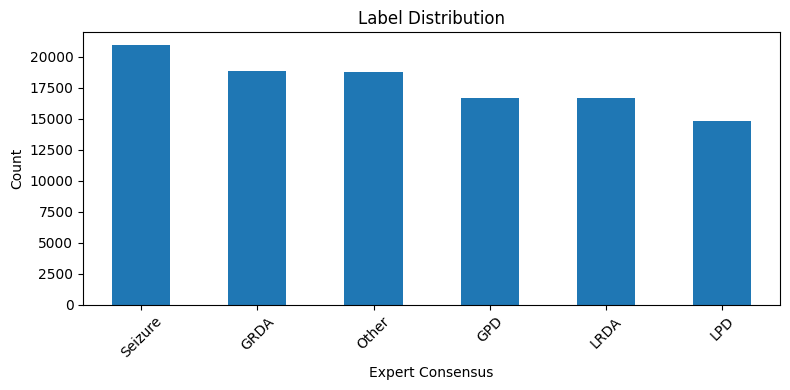

In [41]:
print(train.shape)
print(train.columns)
print(train["expert_consensus"].value_counts())

label_counts = train["expert_consensus"].value_counts()

plt.figure(figsize=(8, 4))
label_counts.plot(kind="bar")
plt.title("Label Distribution")
plt.xlabel("Expert Consensus")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

-> LPD (1st), LRDA/GPD

In [42]:
import pandas as pd

# 예시 eeg_id 하나 뽑기
sample_id = train.iloc[0]["eeg_id"]

# parquet 불러오기
eeg = pd.read_parquet(f"/Users/pitzsb1/Documents/train_eegs/{sample_id}.parquet")

print(eeg.shape)
print(eeg.columns)
eeg.head()

(18000, 20)
Index(['Fp1', 'F3', 'C3', 'P3', 'F7', 'T3', 'T5', 'O1', 'Fz', 'Cz', 'Pz',
       'Fp2', 'F4', 'C4', 'P4', 'F8', 'T4', 'T6', 'O2', 'EKG'],
      dtype='str')


,Fp1,F3,C3,P3,F7,T3,T5,O1,Fz,Cz,Pz,Fp2,F4,C4,P4,F8,T4,T6,O2,EKG
0,-80.519997,-70.540001,-80.110001,-108.750000,-120.330002,-88.620003,-101.750000,-104.489998,-99.129997,-90.389999,-97.040001,-77.989998,-88.830002,-112.120003,-108.110001,-95.949997,-98.360001,-121.730003,-106.449997,7.920000
1,-80.449997,-70.330002,-81.760002,-107.669998,-120.769997,-90.820000,-104.260002,-99.730003,-99.070000,-92.290001,-96.019997,-84.500000,-84.989998,-115.610001,-103.860001,-97.470001,-89.290001,-115.500000,-102.059998,29.219999
2,-80.209999,-75.870003,-82.050003,-106.010002,-117.500000,-87.489998,-99.589996,-96.820000,-119.680000,-99.360001,-91.110001,-99.440002,-104.589996,-127.529999,-113.349998,-95.870003,-96.019997,-123.879997,-105.790001,45.740002
3,-84.709999,-75.339996,-87.480003,-108.970001,-121.410004,-94.750000,-105.370003,-100.279999,-113.839996,-102.059998,-95.040001,-99.230003,-101.220001,-125.769997,-111.889999,-97.459999,-97.180000,-128.940002,-109.889999,83.870003
4,-90.570000,-80.790001,-93.000000,-113.870003,-129.960007,-102.860001,-118.599998,-101.099998,-107.660004,-102.339996,-98.510002,-95.300003,-88.930000,-115.639999,-99.800003,-97.500000,-88.730003,-114.849998,-100.250000,97.769997


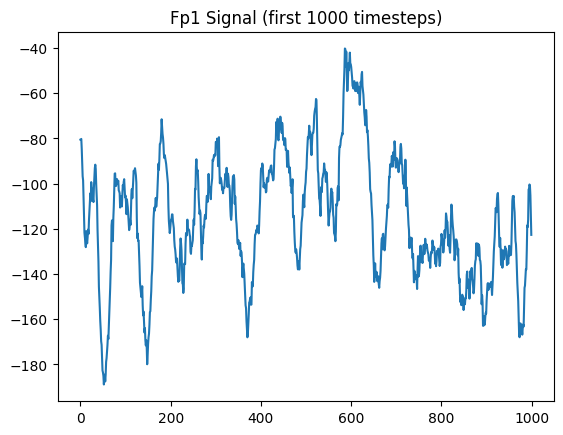

In [43]:
import matplotlib.pyplot as plt

# 한 채널만 보기 (예: Fp1)
plt.plot(eeg["Fp1"][:1000])
plt.title("Fp1 Signal (first 1000 timesteps)")
plt.show()

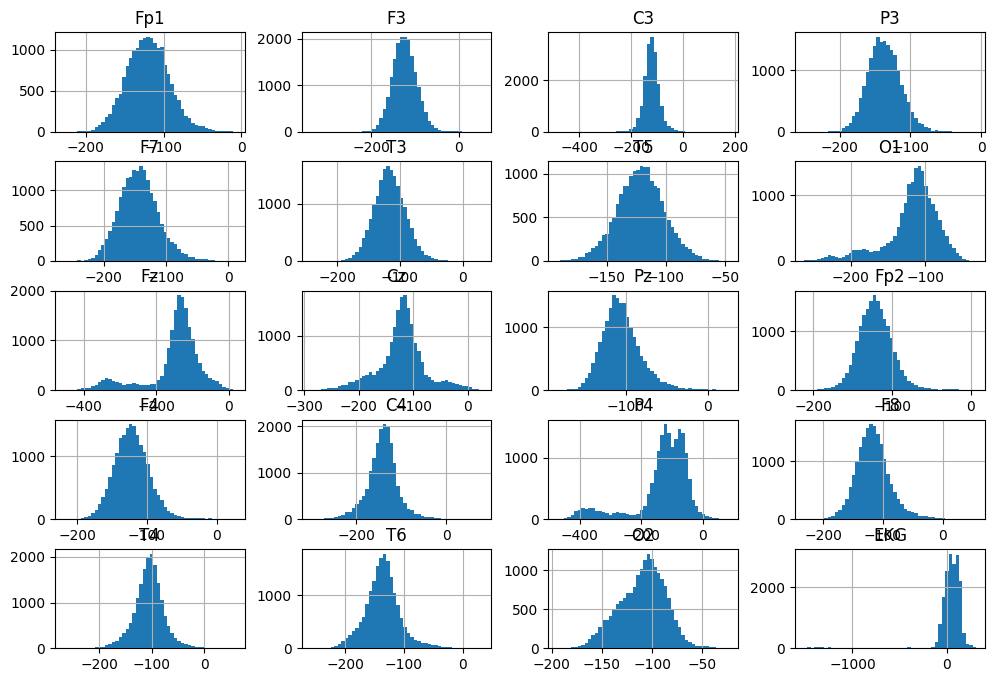

In [44]:
eeg.hist(figsize=(12,8), bins=50)
plt.show()

-> 대부분 종 모양(정규분포). Diffusion 데이터로 굿

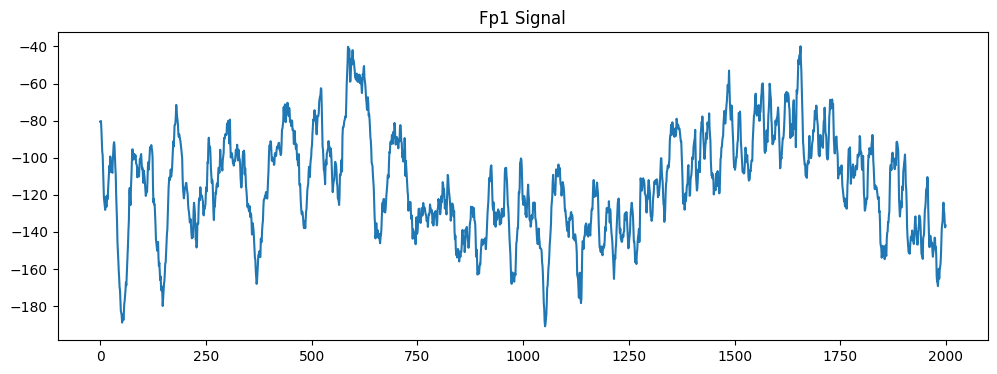

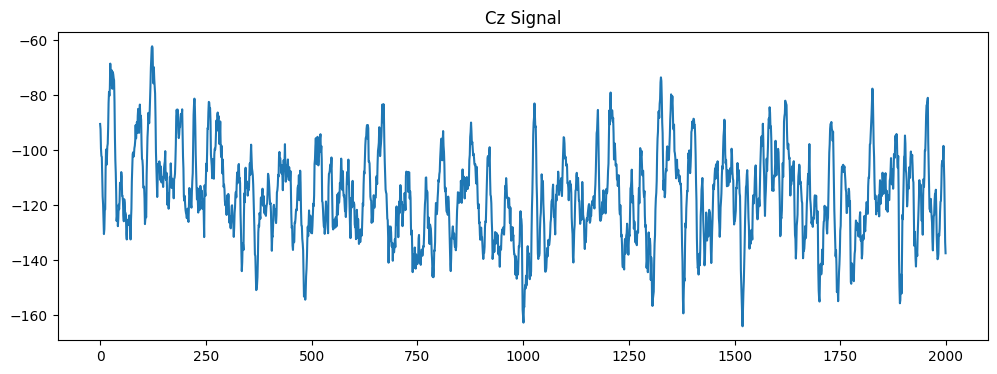

In [45]:
plt.figure(figsize=(12,4))
plt.plot(eeg["Fp1"][:2000])
plt.title("Fp1 Signal")
plt.show()

plt.figure(figsize=(12,4))
plt.plot(eeg["Cz"][:2000])
plt.title("Cz Signal")
plt.show()

In [46]:
EEG_CHANNELS = [
    "Fp1", "F3", "C3", "P3", "F7", "T3", "T5", "O1",
    "Fz", "Cz", "Pz",
    "Fp2", "F4", "C4", "P4", "F8", "T4", "T6", "O2"
]

# 일단 EKG는 제외 

# NeuroStat 모델은 분석 모델이라 EKG 사용 가능, NeruoDiffusion 모델은 EEG 분포에 집중하는 생성 모델이기에 EKG는 제외하는 방향

In [47]:
# EEG 하나를 Diffusion 입력용 segment로 자르기

import numpy as np

sampling_rate = 200
window_sec = 10
window_size = sampling_rate * window_sec  # 2000

segment = eeg[EEG_CHANNELS].iloc[:window_size].values
segment = segment.T

print(segment.shape)

(19, 2000)


In [48]:
mean = segment.mean(axis=1, keepdims=True)
std = segment.std(axis=1, keepdims=True) + 1e-6

segment_norm = (segment - mean) / std

print(segment_norm.mean())
print(segment_norm.std())

-6.725914e-08
0.9999999


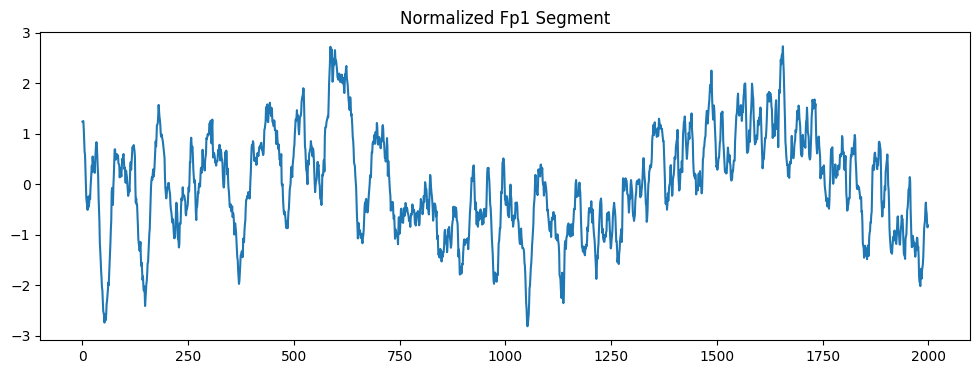

In [49]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))
plt.plot(segment_norm[0])
plt.title("Normalized Fp1 Segment")
plt.show()

In [50]:
# 여러 segment 만들기 (sliding window)
# sliding window로 데이터 겹치게 자르기(같은 신호 여러 관점에서 확인)

def make_segments(eeg, window_size=2000, stride=1000):
    segments = []
    
    for start in range(0, len(eeg) - window_size, stride):
        seg = eeg.iloc[start:start+window_size][EEG_CHANNELS].values.T
        
        # normalization
        mean = seg.mean(axis=1, keepdims=True)
        std = seg.std(axis=1, keepdims=True) + 1e-6
        seg = (seg - mean) / std
        
        segments.append(seg)
    
    return segments

In [51]:
# EEG 하나에서 여러 segment 만들기

segments = make_segments(eeg)

print(len(segments))
print(segments[0].shape)

16
(19, 2000)


In [52]:
# 여러 EEG에서 segment 만들기

all_segments = []

for i in range(100):  # 일단 100개만 테스트
    eeg_id = train.iloc[i]["eeg_id"]
    eeg = pd.read_parquet(f"/Users/pitzsb1/Documents/train_eegs/{eeg_id}.parquet")
    
    segs = make_segments(eeg)
    all_segments.extend(segs)

print(len(all_segments))

1304


In [53]:
# Pytorch는 리스트 못 읽기 때문에 numpy array로 바꿔주기

import numpy as np

X = np.array(all_segments)

print(X.shape)

(1304, 19, 2000)


In [54]:
# 각 segment에 레이블 붙이기

labels = []

for i in range(100):
    label = train.iloc[i]["expert_consensus"]
    
    eeg_id = train.iloc[i]["eeg_id"]
    eeg = pd.read_parquet(f"/Users/pitzsb1/Documents/train_eegs/{eeg_id}.parquet")
    
    segs = make_segments(eeg)
    
    labels.extend([label] * len(segs))

In [55]:
!pip install torch

In [56]:
import numpy as np

X = np.array(all_segments)

print(X.shape)

import torch
from torch.utils.data import Dataset

class EEGDataset(Dataset):
    def __init__(self, X):
        self.X = torch.tensor(X, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx]

dataset = EEGDataset(X)

(1304, 19, 2000)


In [57]:
from torch.utils.data import DataLoader

dataloader = DataLoader(
    dataset,
    batch_size=16,
    shuffle=True
)

batch = next(iter(dataloader))
print(batch.shape)

torch.Size([16, 19, 2000])


In [58]:
# torch dataset 만들기

import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader

# 1. list of segments -> numpy array
X = np.array(all_segments)

print("X shape:", X.shape)  # 예상: (1304, 19, 2000)

# 2. Torch Dataset
class EEGDataset(Dataset):
    def __init__(self, X):
        self.X = torch.tensor(X, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx]

# 3. dataset 객체 만들기
dataset = EEGDataset(X)

print("Dataset length:", len(dataset))
print("One sample shape:", dataset[0].shape)

# 4. DataLoader 만들기
dataloader = DataLoader(
    dataset,
    batch_size=16,
    shuffle=True
)

# 5. batch 확인
batch = next(iter(dataloader))

print("Batch shape:", batch.shape)

X shape: (1304, 19, 2000)
Dataset length: 1304
One sample shape: torch.Size([19, 2000])
Batch shape: torch.Size([16, 19, 2000])


In [59]:
# ★ Diffusion의 꽃... noise 추가하기
# eeg에 일부러 noise 섞기 -> 모델에게 noise 뭐였는지 맞히게 하기 -> 모델이 noise 제거하는 법 배우게 하기
# 나중에는 noise 섞인 eeg 줬을 때 원래 eeg 복원하는 모델로 발전시킬 수 있음
# Diffusion에 랜덤 노이즈를 넣어서, 새로운 eeg 신호를 생성 -> 데이터 증강!

import torch

def add_noise(x, noise_level=0.1):
    noise = torch.randn_like(x)
    x_noisy = x + noise_level * noise
    return x_noisy, noise

batch = next(iter(dataloader))

x_noisy, noise = add_noise(batch, noise_level=0.2)

print("Original:", batch.shape)
print("Noisy:", x_noisy.shape)
print("Noise:", noise.shape)

Original: torch.Size([16, 19, 2000])
Noisy: torch.Size([16, 19, 2000])
Noise: torch.Size([16, 19, 2000])


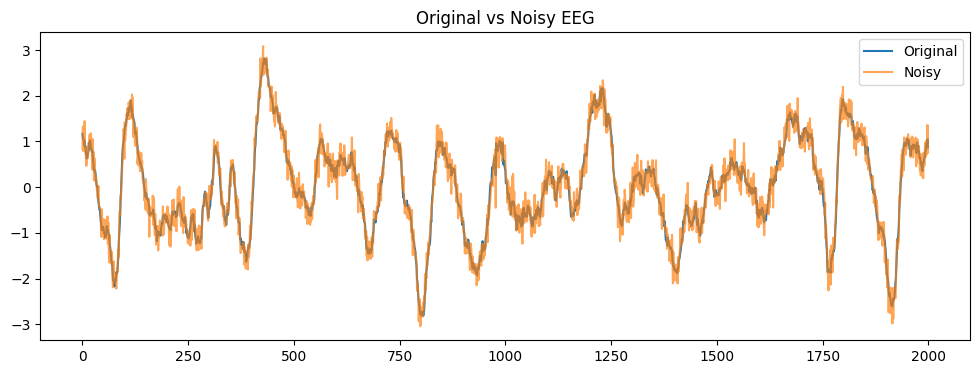

In [60]:
import matplotlib.pyplot as plt

sample_idx = 0
channel_idx = 0  # Fp1

plt.figure(figsize=(12,4))
plt.plot(batch[sample_idx, channel_idx].numpy(), label="Original")
plt.plot(x_noisy[sample_idx, channel_idx].numpy(), label="Noisy", alpha=0.7)
plt.legend()
plt.title("Original vs Noisy EEG")
plt.show()

In [61]:
# 간단한 모델 실험

import torch.nn as nn

class SimpleDenoiser(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.net = nn.Sequential(
            nn.Conv1d(19, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            
            nn.Conv1d(64, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            
            nn.Conv1d(64, 19, kernel_size=3, padding=1)
        )
    
    def forward(self, x):
        return self.net(x)

In [72]:
model = SimpleDenoiser()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
loss_fn = nn.MSELoss()

for epoch in range(3):
    for batch in dataloader:
        
        x = batch  # clean EEG
        noise = torch.randn_like(x) # random noise
        x_noisy = x + 0.2 * noise # noisy EEG
        
        pred_noise = model(x_noisy) # 모델이 noise 예측하게 하기
        
        loss = loss_fn(pred_noise, noise) # 모델이 예측한 noise와 실제 noise 비교
        
        optimizer.zero_grad() # gradient 초기화
        loss.backward() # backpropagation
        optimizer.step() # 모델 업데이트
    
    print(f"Epoch {epoch}, Loss: {loss.item():.4f}")

Epoch 0, Loss: 0.9817
Epoch 1, Loss: 0.9579
Epoch 2, Loss: 0.9245


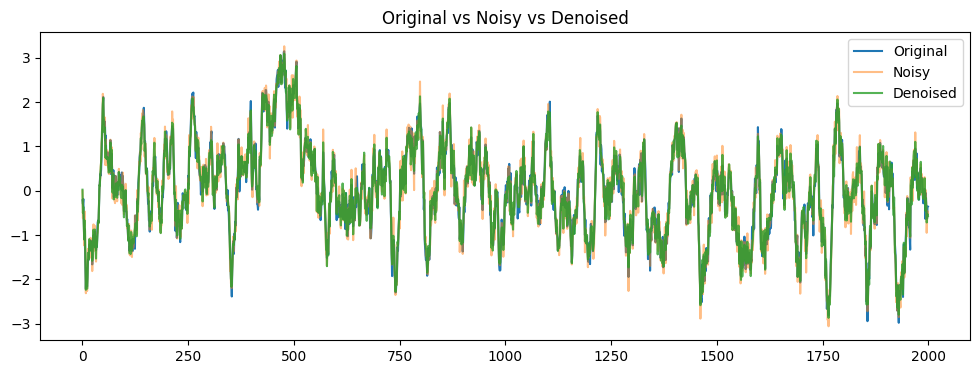

In [ ]:
# noise 제거 시각화

model.eval()

batch = next(iter(dataloader))
x = batch

noise = torch.randn_like(x)
x_noisy = x + 0.2 * noise

with torch.no_grad():
    pred_noise = model(x_noisy)
    x_denoised = x_noisy - 0.2 * pred_noise

import matplotlib.pyplot as plt

sample_idx = 0
channel_idx = 0

plt.figure(figsize=(12,4))
plt.plot(x[sample_idx, channel_idx].numpy(), label="Original")
plt.plot(x_noisy[sample_idx, channel_idx].numpy(), label="Noisy", alpha=0.5)
plt.plot(x_denoised[sample_idx, channel_idx].numpy(), label="Denoised", alpha=0.8)
plt.legend()
plt.title("Original vs Noisy vs Denoised")
plt.show()

In [ ]:
error_noisy = torch.abs(x_noisy - x)
error_denoised = torch.abs(x_denoised - x)

print("Noisy error:", error_noisy.mean().item())
print("Denoised error:", error_denoised.mean().item())

Noisy error: 0.1596016138792038
Denoised error: 0.11662746965885162


In [ ]:
# diffusion schedule (noise level 점점 줄이기)
# t = 0 -> 거의 깨끗, t = 50 -> 중간 정도, t = 99 -> 엄청 노이즈 많음

import torch

T = 100  # diffusion step 수

betas = torch.linspace(1e-4, 0.02, T)
alphas = 1.0 - betas
alpha_bars = torch.cumprod(alphas, dim=0) # 얼마나 원본이 남아있는지 보여주는 지표

print(alpha_bars.shape)

torch.Size([100])


In [ ]:
# timestep에 따라 noise level 조절해서 EEG에 noise 추가 (실제로 이행)
# t 단계에 맞춰 노이즈 적절히 섞기

def q_sample(x_start, t, noise=None):
    if noise is None:
        noise = torch.randn_like(x_start)

    alpha_bar_t = alpha_bars[t].view(-1, 1, 1)

    x_noisy = torch.sqrt(alpha_bar_t) * x_start + torch.sqrt(1 - alpha_bar_t) * noise

    return x_noisy, noise

In [ ]:
# 모델이 timestep 정보도 같이 받도록 수정 (t에 따라 noise level 달라지니까)

import torch.nn as nn

class TimeEmbedding(nn.Module):
    def __init__(self, T, dim):
        super().__init__()
        self.embedding = nn.Embedding(T, dim)

    def forward(self, t):
        return self.embedding(t)


class DiffusionDenoiser(nn.Module):
    def __init__(self, T=100):
        super().__init__()

        self.time_embed = TimeEmbedding(T, 64)

        self.conv1 = nn.Conv1d(19, 64, kernel_size=3, padding=1)
        self.conv2 = nn.Conv1d(64, 64, kernel_size=3, padding=1)
        self.conv3 = nn.Conv1d(64, 19, kernel_size=3, padding=1)

        self.act = nn.ReLU()

    def forward(self, x, t):
        t_emb = self.time_embed(t)          # [B, 64]
        t_emb = t_emb.unsqueeze(-1)         # [B, 64, 1]

        h = self.conv1(x)                   # [B, 64, 2000]
        h = h + t_emb                       # timestep 정보 추가
        h = self.act(h)

        h = self.act(self.conv2(h))
        out = self.conv3(h)

        return out

In [ ]:
import torch
import torch.nn as nn

# 모델 새로 만들기
model = DiffusionDenoiser(T=T)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
loss_fn = nn.MSELoss()

num_epochs = 50   # 👈 epoch 늘리는 곳

for epoch in range(num_epochs):
    total_loss = 0

    for batch in dataloader:
        x = batch

        batch_size = x.shape[0]

        # 각 샘플마다 랜덤 timestep 선택
        t = torch.randint(0, T, (batch_size,))

        # timestep에 맞게 noise 추가
        x_noisy, noise = q_sample(x, t)

        # 모델이 noise 예측
        pred_noise = model(x_noisy, t)

        # 실제 noise와 예측 noise 비교
        loss = loss_fn(pred_noise, noise)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(dataloader)
    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {avg_loss:.4f}")

Epoch 1/50, Loss: 0.8832
Epoch 2/50, Loss: 0.5959
Epoch 3/50, Loss: 0.5169
Epoch 4/50, Loss: 0.4929
Epoch 5/50, Loss: 0.4706
Epoch 6/50, Loss: 0.4552
Epoch 7/50, Loss: 0.4566
Epoch 8/50, Loss: 0.4464
Epoch 9/50, Loss: 0.4330
Epoch 10/50, Loss: 0.4371
Epoch 11/50, Loss: 0.4248
Epoch 12/50, Loss: 0.4204
Epoch 13/50, Loss: 0.4113
Epoch 14/50, Loss: 0.4211
Epoch 15/50, Loss: 0.4104
Epoch 16/50, Loss: 0.4027
Epoch 17/50, Loss: 0.4027
Epoch 18/50, Loss: 0.3936
Epoch 19/50, Loss: 0.3884
Epoch 20/50, Loss: 0.3966
Epoch 21/50, Loss: 0.3880
Epoch 22/50, Loss: 0.4028
Epoch 23/50, Loss: 0.3867
Epoch 24/50, Loss: 0.3883
Epoch 25/50, Loss: 0.3879
Epoch 26/50, Loss: 0.3748
Epoch 27/50, Loss: 0.3914
Epoch 28/50, Loss: 0.3827
Epoch 29/50, Loss: 0.3849
Epoch 30/50, Loss: 0.3801
Epoch 31/50, Loss: 0.3938
Epoch 32/50, Loss: 0.3822
Epoch 33/50, Loss: 0.3708
Epoch 34/50, Loss: 0.3757
Epoch 35/50, Loss: 0.3631
Epoch 36/50, Loss: 0.3681
Epoch 37/50, Loss: 0.3750
Epoch 38/50, Loss: 0.3585
Epoch 39/50, Loss: 0.

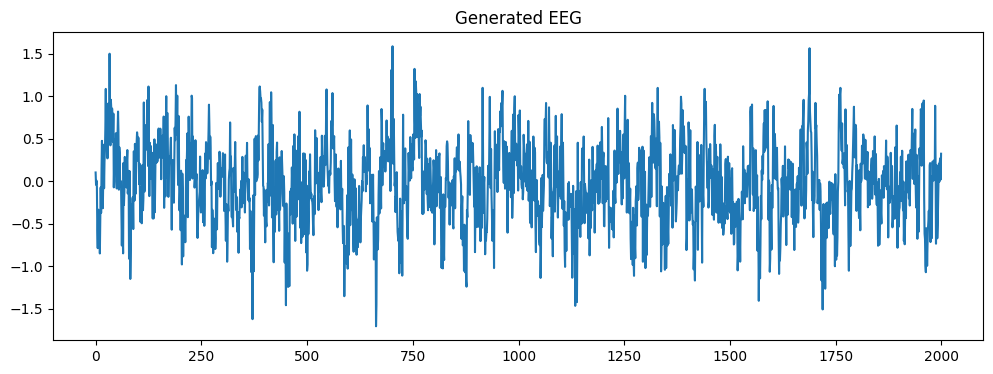

In [ ]:
generated = sample(model, shape=(1, 19, 2000), T=T)

import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))
plt.plot(generated[0, 0].detach().numpy())
plt.title("Generated EEG")
plt.show()

-> 정규화된 EEG 느낌이긴 한데 주기성/패턴 없음

In [78]:
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader

# =========================
# 1. 설정
# =========================

EEG_CHANNELS = [
    "Fp1", "F3", "C3", "P3", "F7", "T3", "T5", "O1",
    "Fz", "Cz", "Pz",
    "Fp2", "F4", "C4", "P4", "F8", "T4", "T6", "O2"
]

sampling_rate = 200
window_sec = 10
window_size = sampling_rate * window_sec

stride = 500
T = 100
num_epochs = 50
batch_size = 16

train_csv_path = "/Users/pitzsb1/Documents/HBAC/train.csv"
eeg_dir = "/Users/pitzsb1/Documents/train_eegs"
save_path = "/Users/pitzsb1/Documents/best_unet_diffusion_model.pth"

if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print("Device:", device)

# =========================
# 2. Segment 생성
# =========================

def make_segments(eeg, window_size=2000, stride=500):
    segments = []

    for start in range(0, len(eeg) - window_size, stride):
        seg = eeg.iloc[start:start+window_size][EEG_CHANNELS].values.T

        mean = seg.mean(axis=1, keepdims=True)
        std = seg.std(axis=1, keepdims=True) + 1e-6
        seg = (seg - mean) / std

        segments.append(seg)

    return segments

train = pd.read_csv(train_csv_path)

all_segments = []
num_files = 200

for i in range(num_files):
    eeg_id = train.iloc[i]["eeg_id"]
    path = f"{eeg_dir}/{eeg_id}.parquet"

    eeg = pd.read_parquet(path)
    segs = make_segments(eeg, window_size=window_size, stride=stride)
    all_segments.extend(segs)

X = np.array(all_segments, dtype=np.float32)

print("X shape:", X.shape)

# =========================
# 3. Dataset / DataLoader
# =========================

class EEGDataset(Dataset):
    def __init__(self, X):
        self.X = torch.tensor(X, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx]

dataset = EEGDataset(X)

dataloader = DataLoader(
    dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0,
    pin_memory=True if device.type == "cuda" else False
)

batch = next(iter(dataloader))
print("Batch shape:", batch.shape)

# =========================
# 4. Diffusion Schedule
# =========================

betas = torch.linspace(1e-4, 0.02, T, device=device)
alphas = 1.0 - betas
alpha_bars = torch.cumprod(alphas, dim=0)

def q_sample(x_start, t, noise=None):
    if noise is None:
        noise = torch.randn_like(x_start)

    alpha_bar_t = alpha_bars[t].view(-1, 1, 1)
    x_noisy = torch.sqrt(alpha_bar_t) * x_start + torch.sqrt(1 - alpha_bar_t) * noise

    return x_noisy, noise

# =========================
# 5. EEG용 1D U-Net Model
# =========================

class UNet1DDenoiser(nn.Module):
    def __init__(self, T=100, base_ch=64):
        super().__init__()

        self.time_embed = nn.Embedding(T, base_ch * 4)

        self.enc1 = nn.Sequential(
            nn.Conv1d(19, base_ch, kernel_size=7, padding=3),
            nn.ReLU(),
            nn.Conv1d(base_ch, base_ch, kernel_size=7, padding=3),
            nn.ReLU()
        )

        self.down1 = nn.Conv1d(base_ch, base_ch * 2, kernel_size=4, stride=2, padding=1)

        self.enc2 = nn.Sequential(
            nn.ReLU(),
            nn.Conv1d(base_ch * 2, base_ch * 2, kernel_size=7, padding=3),
            nn.ReLU()
        )

        self.down2 = nn.Conv1d(base_ch * 2, base_ch * 4, kernel_size=4, stride=2, padding=1)

        self.mid = nn.Sequential(
            nn.ReLU(),
            nn.Conv1d(base_ch * 4, base_ch * 4, kernel_size=7, padding=3),
            nn.ReLU(),
            nn.Conv1d(base_ch * 4, base_ch * 4, kernel_size=7, padding=3),
            nn.ReLU()
        )

        self.up1 = nn.ConvTranspose1d(base_ch * 4, base_ch * 2, kernel_size=4, stride=2, padding=1)

        self.dec1 = nn.Sequential(
            nn.ReLU(),
            nn.Conv1d(base_ch * 4, base_ch * 2, kernel_size=7, padding=3),
            nn.ReLU()
        )

        self.up2 = nn.ConvTranspose1d(base_ch * 2, base_ch, kernel_size=4, stride=2, padding=1)

        self.dec2 = nn.Sequential(
            nn.ReLU(),
            nn.Conv1d(base_ch * 2, base_ch, kernel_size=7, padding=3),
            nn.ReLU()
        )

        self.out = nn.Conv1d(base_ch, 19, kernel_size=7, padding=3)

    def forward(self, x, t):
        t_emb = self.time_embed(t).unsqueeze(-1)

        e1 = self.enc1(x)
        d1 = self.down1(e1)

        e2 = self.enc2(d1)
        d2 = self.down2(e2)

        mid = d2 + t_emb
        mid = self.mid(mid)

        u1 = self.up1(mid)
        u1 = torch.cat([u1, e2], dim=1)
        u1 = self.dec1(u1)

        u2 = self.up2(u1)
        u2 = torch.cat([u2, e1], dim=1)
        u2 = self.dec2(u2)

        return self.out(u2)

model = UNet1DDenoiser(T=T, base_ch=64).to(device)

print("Model device:", next(model.parameters()).device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
loss_fn = nn.MSELoss()

# =========================
# 6. Training Loop
# =========================

loss_history = []
best_loss = float("inf")

for epoch in range(num_epochs):
    model.train()
    total_loss = 0

    for batch_idx, batch in enumerate(dataloader):
        x = batch.to(device)

        batch_size_now = x.shape[0]
        t = torch.randint(0, T, (batch_size_now,), device=device)

        x_noisy, noise = q_sample(x, t)
        pred_noise = model(x_noisy, t)

        loss = loss_fn(pred_noise, noise)

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item()

        if batch_idx % 20 == 0:
            print(
                f"Epoch {epoch+1}/{num_epochs} | "
                f"Batch {batch_idx}/{len(dataloader)} | "
                f"Loss {loss.item():.4f}"
            )

    avg_loss = total_loss / len(dataloader)
    loss_history.append(avg_loss)

    if avg_loss < best_loss:
        best_loss = avg_loss
        torch.save(model.state_dict(), save_path)
        print(f"Epoch {epoch+1}/{num_epochs}, Avg Loss: {avg_loss:.4f} ✅ saved")
    else:
        print(f"Epoch {epoch+1}/{num_epochs}, Avg Loss: {avg_loss:.4f}")

# =========================
# 7. Loss Plot
# =========================

plt.figure(figsize=(8, 4))
plt.plot(loss_history)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.show()

# =========================
# 8. Best Model Load
# =========================

model.load_state_dict(torch.load(save_path, map_location=device))
model.eval()

# =========================
# 9. Reverse Sampling
# =========================

def sample(model, shape, T):
    model.eval()
    x = torch.randn(shape, device=device)

    for t in reversed(range(T)):
        t_batch = torch.full((shape[0],), t, dtype=torch.long, device=device)

        with torch.no_grad():
            pred_noise = model(x, t_batch)

        alpha = alphas[t]
        alpha_bar = alpha_bars[t]
        beta = betas[t]

        if t > 0:
            noise = torch.randn_like(x)
        else:
            noise = torch.zeros_like(x)

        x = (
            1 / torch.sqrt(alpha)
        ) * (
            x - (beta / torch.sqrt(1 - alpha_bar)) * pred_noise
        ) + torch.sqrt(beta) * noise

    return x

generated = sample(model, shape=(1, 19, 2000), T=T)

print("Generated shape:", generated.shape)

# =========================
# 10. Plot Generated EEG
# =========================

generated_cpu = generated.detach().cpu()

plt.figure(figsize=(12, 4))
plt.plot(generated_cpu[0, 0].numpy())
plt.title("Generated EEG - Fp1")
plt.show()

Device: mps
X shape: (6085, 19, 2000)
Batch shape: torch.Size([16, 19, 2000])
Model device: mps:0
Epoch 1/50 | Batch 0/381 | Loss 1.0043
Epoch 1/50 | Batch 20/381 | Loss 0.9929
Epoch 1/50 | Batch 40/381 | Loss 0.9811
Epoch 1/50 | Batch 60/381 | Loss 0.9455
Epoch 1/50 | Batch 80/381 | Loss 0.9339
Epoch 1/50 | Batch 100/381 | Loss 0.8966
Epoch 1/50 | Batch 120/381 | Loss 0.8586
Epoch 1/50 | Batch 140/381 | Loss 0.8282
Epoch 1/50 | Batch 160/381 | Loss 0.7697
Epoch 1/50 | Batch 180/381 | Loss 0.7135
Epoch 1/50 | Batch 200/381 | Loss 0.7699
Epoch 1/50 | Batch 220/381 | Loss 0.7147
Epoch 1/50 | Batch 240/381 | Loss 0.6741
Epoch 1/50 | Batch 260/381 | Loss 0.6680
Epoch 1/50 | Batch 280/381 | Loss 0.6322
Epoch 1/50 | Batch 300/381 | Loss 0.6935
Epoch 1/50 | Batch 320/381 | Loss 0.6491
Epoch 1/50 | Batch 340/381 | Loss 0.6587


KeyboardInterrupt: 